<a href="https://colab.research.google.com/github/Luyao-Xu/3-Class-Speech-Command-Classification/blob/main/02_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Classical Machine Learning
### Load and Flatten the Data
Classical ML models can't read a 2D MFCC image directly. so we need to flatten the 40 x 32 MFCC matrix into a single 1,280-length vector.

In [ ]:
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

processed_path = '/content/drive/MyDrive/speech_commands_project/data/processed'

X_train = np.load(os.path.join(processed_path, 'X_train.npy'))
y_train = np.load(os.path.join(processed_path, 'y_train.npy'))
X_test = np.load(os.path.join(processed_path, 'X_test.npy'))
y_test = np.load(os.path.join(processed_path, 'y_test.npy'))

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Ready to train on {X_train_flat.shape[0]} samples with {X_train_flat.shape[1]} features each.")

Ready to train on 7492 samples with 1280 features each.


### Training the Models
##### Train Random Forest (The Baseline): Build multiple decision trees to classify the 1,280 features in your flattened MFCCs.


In [ ]:
# n_estimators=100 is a good starting point for robustness
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train)

rf_preds = rf_model.predict(X_test_flat)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.2%}")

Random Forest Accuracy: 78.76%


##### Train SVM (The Geometric Comparison): Try to find the optimal hyperplane that separates "tree," "three," and "two" in the feature space.

In [ ]:
# RBF kernel handles non-linear relationships in speech audio data
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train_flat, y_train)

svm_preds = svm_model.predict(X_test_flat)

svm_acc = accuracy_score(y_test, svm_preds)
print(f" SVM Accuracy: {svm_acc:.2%}")

 SVM Accuracy: 80.26%



--- Random Forest Classification Report ---
              precision    recall  f1-score   support

        tree       0.68      0.36      0.47       176
       three       0.74      0.86      0.80       373
         two       0.86      0.91      0.89       388

    accuracy                           0.79       937
   macro avg       0.76      0.71      0.72       937
weighted avg       0.78      0.79      0.77       937



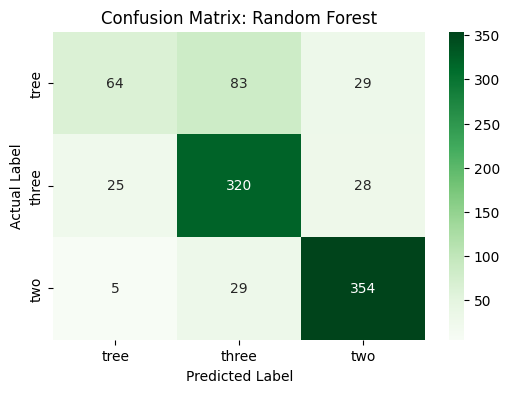


--- SVM Classification Report ---
              precision    recall  f1-score   support

        tree       0.68      0.51      0.58       176
       three       0.80      0.83      0.81       373
         two       0.85      0.91      0.88       388

    accuracy                           0.80       937
   macro avg       0.77      0.75      0.76       937
weighted avg       0.80      0.80      0.80       937



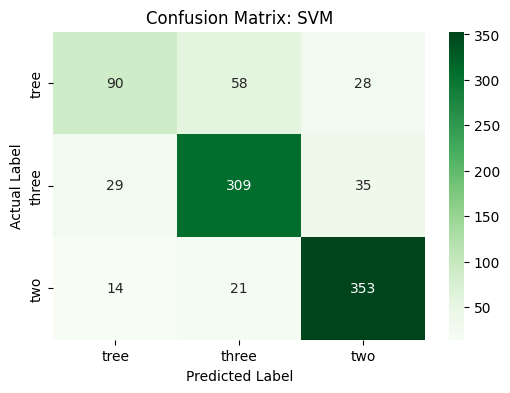

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['tree', 'three', 'two']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['tree', 'three', 'two'],
                yticklabels=['tree', 'three', 'two'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluate_model(y_test, rf_preds, "Random Forest")
evaluate_model(y_test, svm_preds, "SVM")

In [ ]:
import time
import sys
import pickle

def get_engineering_metrics(model, X_train, X_test, model_name):
    start_train = time.time()
    model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
    end_train = time.time()
    train_time = end_train - start_train

    # 2. Inference Speed (CPU) - Time to predict 100 samples divided by 100
    start_inf = time.time()
    model.predict(X_test.reshape(X_test.shape[0], -1))
    end_inf = time.time()
    inf_speed = (end_inf - start_inf) / len(X_test) * 1000 # In milliseconds

    # 3. Model Size (on Disk/Memory)
    # We serialize the model to see how many bytes it takes
    model_bytes = sys.getsizeof(pickle.dumps(model))
    model_size_kb = model_bytes / 1024

    print(f"\n--- {model_name} Engineering Metrics ---")
    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Inference Time per sample: {inf_speed:.4f} ms")
    print(f"Model Size: {model_size_kb:.2f} KB")

    return train_time, inf_speed, model_size_kb

# Execute for both
rf_metrics = get_engineering_metrics(rf_model, X_train, X_test, "Random Forest")
svm_metrics = get_engineering_metrics(svm_model, X_train, X_test, "SVM")


--- Random Forest Engineering Metrics ---
Training Time: 52.7517 seconds
Inference Time per sample: 0.0353 ms
Model Size: 14796.05 KB

--- SVM Engineering Metrics ---
Training Time: 216.1687 seconds
Inference Time per sample: 7.2491 ms
Model Size: 53034.71 KB
